# FAIR Universe - Weak Lensing ML Uncertainty Challenge
## Phase 1 Starting Kit: Convolutional Neural Network Direct Prediction
***

In the universe, massive objects like galaxies and clusters of galaxies bend the path of light traveling near them — a phenomenon known as gravitational lensing, as predicted by Einstein’s general relativity. When this bending is subtle, it’s known as weak gravitational lensing. It slightly distorts the shapes of distant galaxies as their light travels through the cosmic web of matter, including dark matter and ordinary matter (baryons), on its way to Earth.

By carefully measuring these tiny distortions across the sky, we can reconstruct convergence maps — essentially cosmic “heat maps” that show where matter is concentrated, even if that matter is invisible. These maps let us trace the hidden structure of the universe.

Crucially, weak lensing maps contain rich cosmological information. By statistically analyzing the patterns in these distortions, we can learn about the universe’s content and evolution. For example, we can estimate how much dark matter and dark energy exist, how fast the universe is expanding, and how structures have grown over time. In this way, weak lensing helps us constrain our cosmological model.

Currently, the most widely accepted model of the universe is called $\Lambda$CDM (Lambda Cold Dark Matter). It describes a universe dominated by dark energy (represented by the Greek letter $\Lambda$, or Lambda) and cold dark matter, with only a small fraction made up of normal matter like stars and planets. Weak lensing is one of the most powerful tools we have to test and refine this model.

The goal of this data challenge is to weak lensing convergence maps to constrain the physical parameters of ΛCDM model, $\Omega_m$, which describes what fraction of the universe’s total energy is made of matter (both normal and dark matter), and $S_8$, which measures of how “clumpy” the matter in the universe is on large scales.

***

`COLAB` determines whether this notebook is running on Google Colab.

# 0 - Imports & Settings

In [1]:
# Pin to GPU 1 for this kernel session
import os, torch
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
# After setting the env var, the visible device index 0 maps to physical GPU 0
if torch.cuda.is_available():
    torch.cuda.set_device(0)
    print('CUDA pinned. Logical device 0 ->', torch.cuda.get_device_name(0))
else:
    print('CUDA not available; running on CPU')

CUDA pinned. Logical device 0 -> NVIDIA L40


In [ ]:
import os
import json
import time
import zipfile
import datetime
import warnings
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils import *

Root directory is /astro/users/lindajin/WL_ML


: 

# 1 - Helper Classes for
- Utitlity Functions
- Data Loading
- Visualizations
- Scoring Functions

### Utility

In [ ]:
class Utility:
    @staticmethod
    def add_noise(data, mask, ng, pixel_size=2.):
        """
        Add noise to a noiseless convergence map.

        Parameters
        ----------
        data : np.array
            Noiseless convergence maps.
        mask : np.array
            Binary mask map.
        ng : float
            Number of galaxies per arcmin². This determines the noise level; a larger number means smaller noise.
        pixel_size : float, optional
            Pixel size in arcminutes (default is 2.0).
        """

        return data + np.random.randn(*data.shape) * 0.4 / (2*ng*pixel_size**2)**0.5 * mask
    
    @staticmethod
    def load_np(data_dir, file_name):
        file_path = os.path.join(data_dir, file_name)
        return np.load(file_path)

    @staticmethod
    def save_np(data_dir, file_name, data):
        file_path = os.path.join(data_dir, file_name)
        np.save(file_path, data)

    @staticmethod
    def save_json_zip(submission_dir, json_file_name, zip_file_name, data):
        """
        Save a dictionary with 'means' and 'errorbars' into a JSON file,
        then compress it into a ZIP file inside submission_dir.

        Parameters
        ----------
        submission_dir : str
            Path to the directory where the ZIP file will be saved.
        file_name : str
            Name of the ZIP file (without extension).
        data : dict
            Dictionary with keys 'means' and 'errorbars'.

        Returns
        -------
        str
            Path to the created ZIP file.
        """
        os.makedirs(submission_dir, exist_ok=True)

        json_path = os.path.join(submission_dir, json_file_name)

        # Save JSON file
        with open(json_path, "w") as f:
            json.dump(data, f)

        # Path to ZIP
        zip_path = os.path.join(submission_dir, zip_file_name)

        # Create ZIP containing only the JSON
        with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as zf:
            zf.write(json_path, arcname=json_file_name)

        # Remove the standalone JSON after zipping
        os.remove(json_path)

        return zip_path

: 

### Data

In [ ]:
class Data:
    def __init__(self, data_dir, USE_PUBLIC_DATASET):
        self.USE_PUBLIC_DATASET = USE_PUBLIC_DATASET
        self.data_dir = data_dir
        self.mask_file = 'WIDE12H_bin2_2arcmin_mask.npy'
        self.viz_label_file = 'label.npy'
        if self.USE_PUBLIC_DATASET:
            self.kappa_file = 'WIDE12H_bin2_2arcmin_kappa.npy'
            self.label_file = self.viz_label_file
            self.Ncosmo = 101  # Number of cosmologies in the entire training data
            self.Nsys = 256    # Number of systematic realizations in the entire training data
            self.test_kappa_file = 'WIDE12H_bin2_2arcmin_kappa_noisy_test.npy'
            self.Ntest = 4000  # Number of instances in the test data
        else:
            self.kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa.npy'
            self.label_file = 'sampled_label.npy'
            self.Ncosmo = 3    # Number of cosmologies in the sampled training data
            self.Nsys = 30     # Number of systematic realizations in the sampled training data
            self.test_kappa_file = 'sampled_WIDE12H_bin2_2arcmin_kappa_noisy_test.npy'
            self.Ntest = 3     # Number of instances in the sampled test data
        
        self.shape = [1424,176] # dimensions of each map 
        self.pixelsize_arcmin = 2 # pixel size in arcmin
        self.pixelsize_radian = self.pixelsize_arcmin / 60 / 180 * np.pi # pixel size in radian
        self.ng = 30  # galaxy number density. This determines the noise level of the experiment. Do not change this number.

    def load_train_data(self):
        self.mask = Utility.load_np(data_dir=self.data_dir, file_name=self.mask_file) # A binary map that shows which parts of the sky are observed and which areas are blocked
        self.kappa = np.zeros((self.Ncosmo, self.Nsys, *self.shape), dtype=np.float16)
        self.kappa[:,:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.kappa_file) # Training convergence maps
        self.label = Utility.load_np(data_dir=self.data_dir, file_name=self.label_file) # Training labels (cosmological and physical paramameters) of each training map
        self.viz_label = Utility.load_np(data_dir=self.data_dir, file_name=self.viz_label_file) # For visualization of parameter distributions

    def load_test_data(self):
        self.kappa_test = np.zeros((self.Ntest, *self.shape), dtype=np.float16)
        self.kappa_test[:,self.mask] = Utility.load_np(data_dir=self.data_dir, file_name=self.test_kappa_file) # Test noisy convergence maps

: 

### Visualization

In [ ]:
class Visualization:
    
    @staticmethod
    def plot_mask(mask):
        plt.figure(figsize=(30,100))
        plt.imshow(mask.T)
        plt.show()

    @staticmethod
    def plot_noiseless_training_convergence_map(kappa):
        plt.figure(figsize=(30,100))
        plt.imshow(kappa[0,0].T, vmin=-0.02, vmax=0.07)
        plt.show()

    @staticmethod
    def plot_noisy_training_convergence_map(kappa, mask, pixelsize_arcmin, ng):
        plt.figure(figsize=(30,100))
        plt.imshow(Utility.add_noise(kappa[0,0], mask, ng, pixelsize_arcmin).T, vmin=-0.02, vmax=0.07)
        plt.show()

    @staticmethod
    def plot_cosmological_parameters_OmegaM_S8(label):
        plt.scatter(label[:,0,0], label[:,0,1])
        plt.xlabel(r'$\Omega_m$')
        plt.ylabel(r'$S_8$')
        plt.show()

    @staticmethod
    def plot_baryonic_physics_parameters(label):
        plt.scatter(label[0,:,2], label[0,:,3])
        plt.xlabel(r'$T_{\mathrm{AGN}}$')
        plt.ylabel(r'$f_0$')
        plt.show()

    @staticmethod
    def plot_photometric_redshift_uncertainty_parameters(label):
        plt.hist(label[0,:,4], bins=20)
        plt.xlabel(r'$\Delta z$')
        plt.show()

: 

### Scoring function

In [ ]:
class Score:
    @staticmethod
    def _score_phase1(true_cosmo, infer_cosmo, errorbar):
        """
        Computes the log-likelihood score for Phase 1 based on predicted cosmological parameters.

        Parameters
        ----------
        true_cosmo : np.ndarray
            Array of true cosmological parameters (shape: [n_samples, n_params]).
        infer_cosmo : np.ndarray
            Array of inferred cosmological parameters from the model (same shape as true_cosmo).
        errorbar : np.ndarray
            Array of standard deviations (uncertainties) for each inferred parameter 
            (same shape as true_cosmo).

        Returns
        -------
        np.ndarray
            Array of scores for each sample (shape: [n_samples]).
        """
        
        sq_error = (true_cosmo - infer_cosmo)**2
        scale_factor = 1000  # This is a constant that scales the error term.
        score = - np.sum(sq_error / errorbar**2 + np.log(errorbar**2) + scale_factor * sq_error, 1)
        score = np.mean(score)
        if score >= -10**6: # Set a minimum of the score (to properly display on Codabench)
            return score
        else:
            return -10**6

: 

# 2 - Load train and test data

The training maps are generated by $N_{\rm cosmo}$ cosmological models, each model contains $N_{\rm sys}$ realizations with different nuisance parameters. So the shape of the training maps kappa is $(N_{\rm cosmo}, N_{\rm sys}, 1424, 176)$. 

Each training map is associated with 5 parameters, so the shape of label is $(N_{\rm cosmo}, N_{\rm sys}, 5)$. The first two parameters are cosmological parameters $\Omega_m$ and $S_8$, while the rest three parameters are nuisance parameters that describe systematic effects and need to be marginalized in the data analysis (two of them describe baryonic effects and the last one describes photometric redshift uncertainties).

In [ ]:
root_dir = os.getcwd()
print("Root directory is", root_dir)

Root directory is /astro/users/lindajin/WL_ML


: 

In [ ]:
USE_PUBLIC_DATASET = True

# USE_PUBLIC_DATASET = True
PUBLIC_DATA_DIR = os.path.join(root_dir, 'input_data/')  # This is only required when you set USE_PUBLIC_DATASET = True

: 

In [ ]:
if not USE_PUBLIC_DATASET:                                         # Testing this startking kit with a tiny sample of the training data (3, 30, 1424, 176)
    DATA_DIR = os.path.join(root_dir, 'input_data/')
else:                                                              # Training your model with all training data (101, 256, 1424, 176)
    DATA_DIR = PUBLIC_DATA_DIR    

: 

### Load the train and test data

In [ ]:
# Initialize Data class object
data_obj = Data(data_dir=DATA_DIR, USE_PUBLIC_DATASET=USE_PUBLIC_DATASET)

# Load train data
data_obj.load_train_data()

# Load test data
data_obj.load_test_data()

: 

In [ ]:
Ncosmo = data_obj.Ncosmo
Nsys = data_obj.Nsys
ng = data_obj.ng

print(f'There are {Ncosmo} cosmological models, each has {Nsys} realizations of nuisance parameters in the training data.')
print(f'We assume a galaxy number density of {ng} per arcmin², which determines the noise level of the experiment.')

There are 101 cosmological models, each has 256 realizations of nuisance parameters in the training data.
We assume a galaxy number density of 30 per arcmin², which determines the noise level of the experiment.


: 

In [ ]:
print(f'Shape of the training data = {data_obj.kappa.shape}')
print(f'Shape of the mask = {data_obj.mask.shape}')
print(f'Shape of the training label = {data_obj.label.shape}')
print(f'Shape of the test data = {data_obj.kappa_test.shape}')

Shape of the training data = (101, 256, 1424, 176)
Shape of the mask = (1424, 176)
Shape of the training label = (101, 256, 5)
Shape of the test data = (4000, 1424, 176)


: 

#### ⚠️ NOTE:
- The original training images are *noiseless* (without any pixel-level noise).
- The original test images is *noisy* (pixel-level noise with galaxy number density $n_g = 30~\text{arcmin}^{-2}$ and pixel size $=2$ arcmin has been added).

- **You will have to add pixel-level noise to the training data through the helper function** `Utility.add_noise`.
    
For example:
```python
    noisy_kappa = Utility.add_noise(data=data_obj.kappa.astype(np.float64), 
                                    mask=data_obj.mask, 
                                    ng=data_obj.ng, 
                                    pixel_size=data_obj.pixelsize_arcmin)
```

The shape of `noisy_kappa` will be the same as the shape of `data_obj.kappa`.

In [ ]:
# # Add the pixel-level noise to the training set (note that this may take some time and large memory)

# np.random.seed(31415)  # Fix the random seed for reproducible results
# noisy_kappa = Utility.add_noise(data=data_obj.kappa.astype(np.float64), 
#                                 mask=data_obj.mask, 
#                                 ng=data_obj.ng, 
#                                 pixel_size=data_obj.pixelsize_arcmin)

: 

In [ ]:
# print(f'Shape of the noised data {noisy_kappa.shape}')

: 

#### ⚠️ NOTE:

If you want to split your own training/validation sets to evaluate your model, we recommend splitting the original training data along `axis = 1` (the 256 realizations of nuisance parameters). This will ensure that there are no intrinsic correlations between the training and validation sets.

In [ ]:
# # Split the data into training and validation sets

# NP_idx = np.arange(Nsys)  # The indices of Nsys nuisance parameter realizations
# split_fraction = 0.2      # Set the fraction of data you want to split (between 0 and 1)
# seed = 5566               # Define your random seed for reproducible results

# train_NP_idx, val_NP_idx = train_test_split(NP_idx, test_size=split_fraction,
#                                             random_state=seed)

# noisy_kappa_train = noisy_kappa[:, train_NP_idx]      # shape = (Ncosmo, len(train_NP_idx), 1424, 176)
# label_train = data_obj.label[:, train_NP_idx]         # shape = (Ncosmo, len(train_NP_idx), 5)
# noisy_kappa_val = noisy_kappa[:, val_NP_idx]          # shape = (Ncosmo, len(val_NP_idx), 1424, 176)
# label_val = data_obj.label[:, val_NP_idx]             # shape = (Ncosmo, len(val_NP_idx), 5)

# Ntrain = label_train.shape[0]*label_train.shape[1]
# Nval = label_val.shape[0]*label_val.shape[1]

# # Save the split data and labels for future usage

# Utility.save_np(data_dir=DATA_DIR, file_name="noisy_kappa_train.npy",data=noisy_kappa_train)
# Utility.save_np(data_dir=DATA_DIR, file_name="label_train.npy",data=label_train)
# Utility.save_np(data_dir=DATA_DIR, file_name="noisy_kappa_val.npy",data=noisy_kappa_val)
# Utility.save_np(data_dir=DATA_DIR, file_name="label_val.npy",data=label_val)

: 

In [ ]:
# Load the saved split data (if you saved it at DATA_DIR before)

noisy_kappa_train = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_train.npy")
clean_kappa_train = Utility.load_np(data_dir=DATA_DIR, file_name="clean_kappa_train.npy")
label_train = Utility.load_np(data_dir=DATA_DIR, file_name="label_train.npy")
noisy_kappa_val = Utility.load_np(data_dir=DATA_DIR, file_name="noisy_kappa_val.npy")
label_val = Utility.load_np(data_dir=DATA_DIR, file_name="label_val.npy")

Ntrain = label_train.shape[0]*label_train.shape[1]
Nval = label_val.shape[0]*label_val.shape[1]

: 

In [ ]:
print(f'Shape of the split training data = {noisy_kappa_train.shape}')
print(f'Shape of the split validation data = {noisy_kappa_val.shape}')

print(f'Shape of the split training labels = {label_train.shape}')
print(f'Shape of the split validation labels = {label_val.shape}')

Shape of the split training data = (101, 204, 1424, 176)
Shape of the split validation data = (101, 52, 1424, 176)
Shape of the split training labels = (101, 204, 5)
Shape of the split validation labels = (101, 52, 5)


: 

In [ ]:
# Reshape the data for CNN
X_train = clean_kappa_train.reshape(Ntrain, *data_obj.shape) ## Use clean maps for training: get mean and std right
X_val = noisy_kappa_val.reshape(Nval, *data_obj.shape)

# Here, we ignore the nuisance parameters and only keep the 2 cosmological parameters
y_train = label_train.reshape(Ntrain, 5)[:, :2]
y_val = label_val.reshape(Nval, 5)[:, :2]

: 

In [ ]:
print(f'Shape of the split training data = {X_train.shape}')
print(f'Shape of the split validation data = {X_val.shape}')

print(f'Shape of the split training labels = {y_train.shape}')
print(f'Shape of the split validation labels = {y_val.shape}')

Shape of the split training data = (20604, 1424, 176)
Shape of the split validation data = (5252, 1424, 176)
Shape of the split training labels = (20604, 2)
Shape of the split validation labels = (5252, 2)


: 

# 3 - Visualization

### 2D training maps

survey mask: a binary map that shows which parts of the sky are observed (yellow) and which areas are blocked (purple)

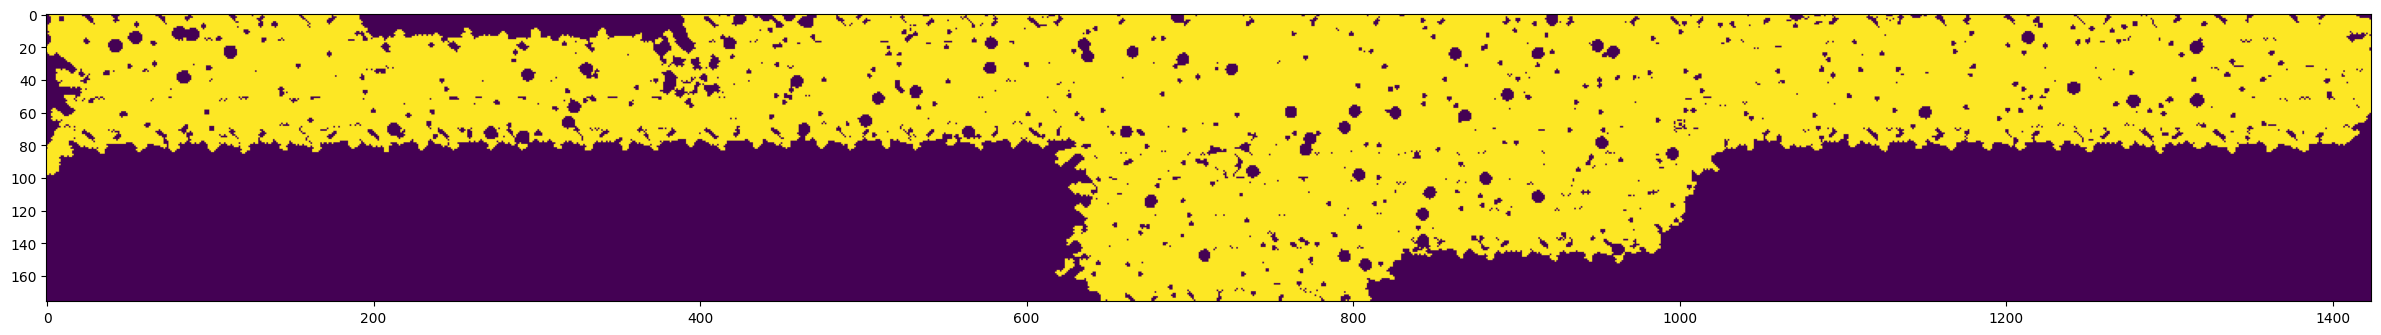

: 

In [ ]:
# mask
Visualization.plot_mask(mask=data_obj.mask)

noiseless training convergence map: The convergence maps show the projected matter density (including dark matter and ordinary matter) in the simulated universe, under the Born approximation. On large scales, we can see the matter forms web-like structures (cosmic web) in the universe. The dense regions in these maps, called dark matter halos, are the sites where galaxies form and reside.

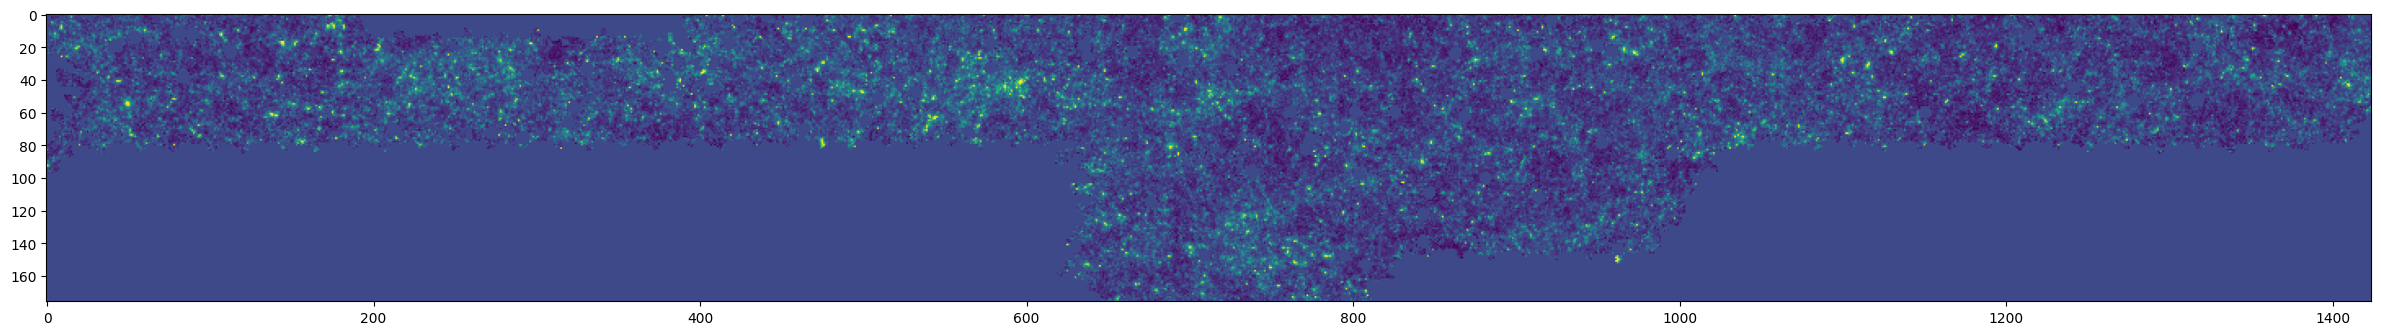

: 

In [ ]:
# noiseless training convergence map
Visualization.plot_noiseless_training_convergence_map(kappa=data_obj.kappa)

noisy training convergence map: We add Gaussian noise to the data. This mimics the observed data. During training the noise can be added on the fly with different realizations.

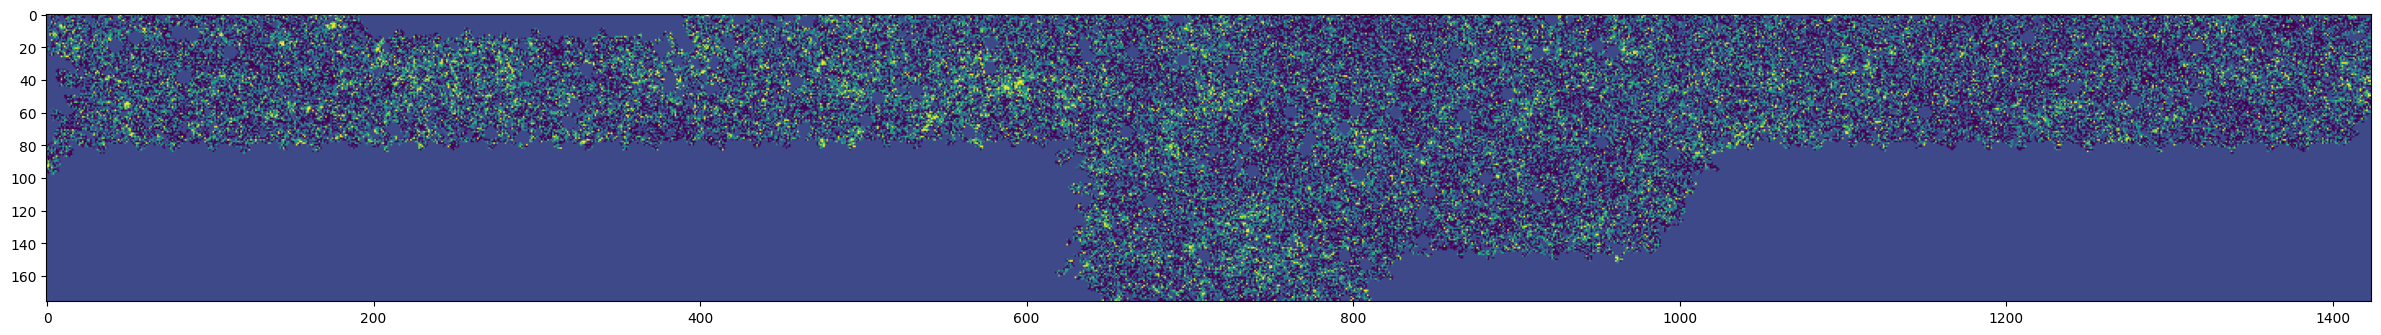

: 

In [ ]:
# noisy training convergence map
Visualization.plot_noisy_training_convergence_map(kappa=data_obj.kappa,
                                                  mask=data_obj.mask,
                                                  pixelsize_arcmin=data_obj.pixelsize_arcmin,
                                                  ng=data_obj.ng)

### Distribution of physical parameters

Distribution of cosmological parameters $\Omega_m$ and $S_8$. The density increases towards fiducial cosmology. Note that this distribution introduces a prior in the analysis. The test data cosmology follows the same distribution as the training data.

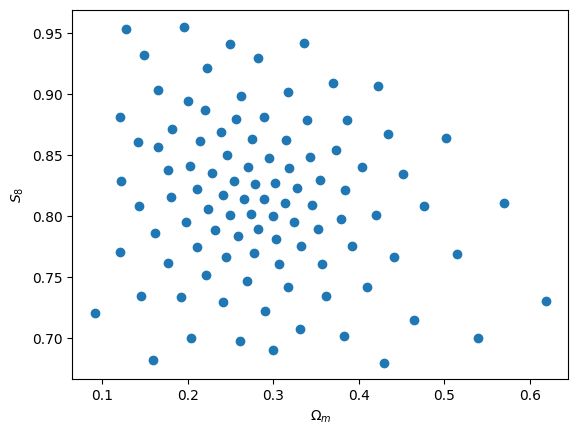

: 

In [ ]:
Visualization.plot_cosmological_parameters_OmegaM_S8(label=data_obj.viz_label)

Distribution of baryonic physics parameters. These are nuisance parameters and should be marginalized in the analysis. They follow a uniform distribution within the prior range $T_{\mathrm{AGN}} \in [7.2, 8.5]$, $f_0 \in [0, 0.0265]$

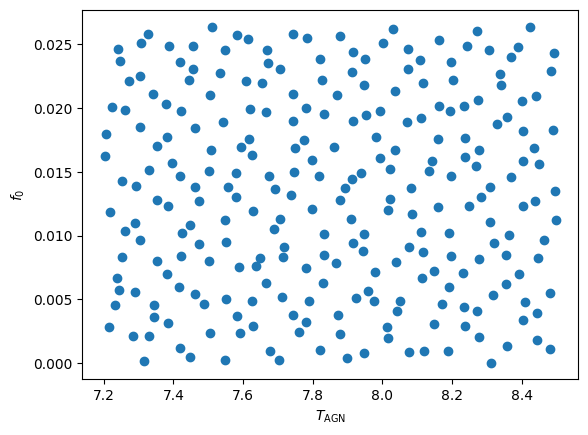

: 

In [ ]:
Visualization.plot_baryonic_physics_parameters(label=data_obj.viz_label)

Distribution of photometric redshift uncertainty parameters. This is a nuisance parameter and should be marginalized in the analysis. It follows a Gaussian distribution with mean 0 and std 0.022

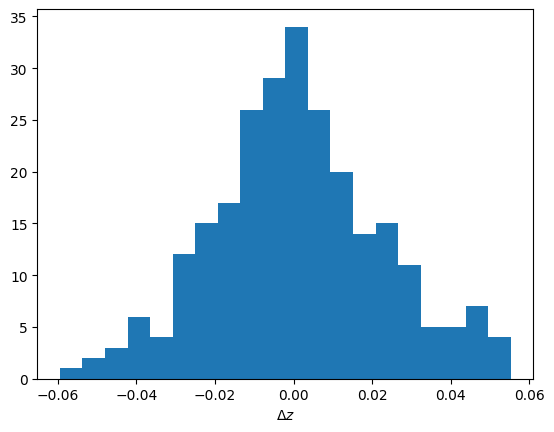

: 

In [ ]:
Visualization.plot_photometric_redshift_uncertainty_parameters(label=data_obj.viz_label)

# 4 - Training

In this notebook, we do not fit any predefined summary statistics to the data and perform MCMC. Instead, we estimate the uncertainties directly using the CNN. This is achieved by optimizing a KL divergence objective function using neural network predictions during training. For each 2D map, the CNN will predict its cosmological parameters $(\hat{\Omega}_m, \hat{S}_8)$ and the standard deviations of the joint Gaussian posterior distribution $(\hat{\sigma}_{\Omega_m}, \hat{\sigma}_{S_8})$.

The loss funciton here is a KL divergence objective function defined by
$$
\text{KL Loss}= \frac{1}{N} \sum_i^{N}\left\{\frac{\left(\hat{\Omega}_{m, i}-\Omega_{m, i}^{\text {truth }}\right)^2}{\hat{\sigma}_{\Omega_m, i}^2}+\frac{\left(\hat{S}_{8, i}-S_{8, i}^{\text {truth }}\right)^2}{\hat{\sigma}_{S_8, i}^2}+\log \left(\hat{\sigma}_{\Omega_m, i}^2\right)+\log \left(\hat{\sigma}_{S_8, i}^2\right)\right\}~.
$$

In [ ]:

# Define your path for saving the trained model
MODEL_NAME = "CNN_direct_clean_small_filter_robust_V15"

class Config:
    IMG_HEIGHT = data_obj.shape[0]
    IMG_WIDTH = data_obj.shape[1]
    
    # Parameters to predict (Omega_m, S_8)
    NUM_TARGETS = 4

    # Training hyperparameters
    BATCH_SIZE = 32
    EPOCHS = 100
    LEARNING_RATE =  4.501717424790536e-05
    WEIGHT_DECAY = 3e-5   # L2 regularization to prevent overfitting
    
    # DEVICE = "mps" if torch.backends.mps.is_available() else "cpu"
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    MODEL_SAVE_PATH = os.path.join(root_dir, f"trained_model/{MODEL_NAME}.pth")
print(f'Devise: {Config.DEVICE}')

Devise: cuda


: 

In [ ]:
# Simple CNN architecture for parameter estimation

class Simple_CNN(nn.Module):
    def __init__(self, height, width, num_targets):
        super(Simple_CNN, self).__init__()
        # Convolutional layers
        self.conv_stack = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=5, stride=2, padding=2),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self._feature_size = self._get_conv_output_size(height, width)
        
        # Fully connected layers (regressor head)
        self.fc_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(self._feature_size, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, num_targets)
        )

    def _get_conv_output_size(self, height, width):
        dummy_input = torch.zeros(1, 1, height, width)
        output = self.conv_stack(dummy_input)
        return int(np.prod(output.size()))

    def forward(self, x):
        x = self.conv_stack(x)
        x = self.fc_stack(x)
        means = x[:, :2]
        log_sigmas = x[:, 2:]    # Predict log(σ) to ensure positivity
        sigmas = torch.exp(log_sigmas)
        return means, sigmas     # Note that means and sigmas here have to be rescaled properly due to standardization

: 

In [ ]:
def KL_div_posterior_loss(pred_means, pred_sigmas, truths):
    """
    A KL divergence loss function that directly optimizes the score function
    
    Inputs:
    - pred_means:   2D tensor (batch_size, 2)
    - pred_sigmas:  2D tensor (batch_size, 2) 
    - truths:       2D tensor (batch_size, 2)
    """
    
    residuals_sq = (pred_means - truths)**2  
    
    loss_terms = residuals_sq / (pred_sigmas**2)
    loss_sum = torch.sum(loss_terms, dim=1)
    
    log_sigma_terms = torch.sum(torch.log(pred_sigmas**2), dim=1)
    loss = torch.mean(loss_sum + log_sigma_terms)
    
    return loss

: 

In [ ]:
def train_epoch(model, dataloader, loss_fn, optimizer, device):
    """Trains the model for one epoch."""
    model.train()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Training")
    for X, y in pbar:
        X, y = X.to(device), y.to(device)

        # Forward pass
        pred_means, pred_sigmas= model(X)
        loss = loss_fn(pred_means, pred_sigmas, y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)


def validate_epoch(model, dataloader, loss_fn, device):
    """Validates the model on the validation/test set."""
    model.eval()
    total_loss = 0
    pbar = tqdm(dataloader, total=len(dataloader), desc="Validating")
    with torch.no_grad():
        for X, y in pbar:
            X, y = X.to(device), y.to(device)
            pred_means, pred_sigmas = model(X)
            total_loss += loss_fn(pred_means, pred_sigmas, y).item()
            
    return total_loss / len(dataloader)

: 

In [ ]:
class CosmologyDataset(Dataset):
    """
    Custom PyTorch Dataset
    """
    
    def __init__(self, data, labels=None,
                 transform=None,
                 label_transform=None):
        self.data = data
        self.labels = labels
        self.transform = transform
        self.label_transform = label_transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.data[idx].astype(np.float32)   # Convert from float16 to float32
        if self.transform:
            image = self.transform(image) 
        if self.labels is not None:
            label = self.labels[idx].astype(np.float32)
            label = torch.from_numpy(label)
            if self.label_transform:
                label = self.label_transform(label)
            return image, label
        else:
            return image

: 

In [ ]:
# Compute the means and stds of the training images (for standardizing the data)

means = np.mean(X_train, dtype=np.float32)
stds = np.std(X_train, dtype=np.float32)

: 

In [ ]:
# Image standardization
from torchvision import transforms
transform = transforms.Compose([
    transforms.ToTensor(),     
    transforms.Normalize(mean=[means], std=[stds]),   
])
print(f"Image stats (from train set): Mean={means}, Std={stds}")

# Label standardization
label_scaler = StandardScaler()
y_train_scaled = label_scaler.fit_transform(y_train)
y_val_scaled = label_scaler.transform(y_val)
print(f"Label stats (from train set): Mean={label_scaler.mean_}, Std={np.sqrt(label_scaler.var_)}")

Image stats (from train set): Mean=-0.00014706686488352716, Std=0.008249041624367237
Label stats (from train set): Mean=[0.29021683 0.81345297], Std=[0.1055216  0.06600116]


: 

In [ ]:
# Load the configuration
config = Config()
print(f"Using device: {config.DEVICE}")

# Create Datasets and DataLoaders
train_dataset = CosmologyDataset(
    data=X_train, 
    labels=y_train_scaled,
    transform=transform
)
val_dataset = CosmologyDataset(
    data=X_val, 
    labels=y_val_scaled,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True) 
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

Using device: cuda


: 

In [ ]:
from model import Simple_CNN, Small_CNN

# Initialize the CNN model
model = Small_CNN(config.IMG_HEIGHT,
                    config.IMG_WIDTH,
                    config.NUM_TARGETS).to(config.DEVICE)

: 

Set `USE_PRETRAINED_MODEL = False` if you want to train a new model.\
Set `USE_PRETRAINED_MODEL = True` if you want to load a pretrained model.

In [ ]:
USE_PRETRAINED_MODEL = True
# USE_PRETRAINED_MODEL = True

: 

In [ ]:
if not USE_PRETRAINED_MODEL:  
    # Train the model
    loss_fn = KL_div_posterior_loss
    optimizer = torch.optim.Adam(model.parameters(),
                                lr=config.LEARNING_RATE,
                                weight_decay=config.WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer,
                                  mode='min',
                                  factor=0.5,
                                  patience=5)
    
    # Training Loop with Early Stopping
    best_val_loss = float('inf')
    early_stop_patience = config.EPOCHS // 4  # Stop if no improvement for 1/4 of total epochs
    epochs_without_improvement = 0
    
    start_time = time.time()
    for epoch in range(config.EPOCHS):
        train_loss = train_epoch(model, train_loader, KL_div_posterior_loss, optimizer, config.DEVICE)
        val_loss = validate_epoch(model, val_loader, KL_div_posterior_loss, config.DEVICE)
    
        scheduler.step(val_loss)    
        print(f"Epoch {epoch+1}/{config.EPOCHS} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")
        
        # Save the best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save(model.state_dict(), config.MODEL_SAVE_PATH)
            print(f"  -> New best model saved to {config.MODEL_SAVE_PATH}")
        else:
            epochs_without_improvement += 1
            print(f"  -> No improvement for {epochs_without_improvement} epoch(s)")
        
        # Early stopping check
        if epochs_without_improvement >= early_stop_patience:
            print(f"\n=== Early Stopping ===")
            print(f"No improvement for {early_stop_patience} epochs. Stopping training.")
            break

    end_time = time.time()
    print(f"\nTraining finished in {(end_time - start_time)/60:.2f} minutes.")
    print(f"Best validation loss: {best_val_loss:.6f}")
    
    model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True)) # Directly load the best model

else:
    # Check if the pretrained model exists
    if os.path.exists(config.MODEL_SAVE_PATH):
        # If the pretrained model exists, load the model
        model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))

    else:
        # If the pretrained model doesn't exist, show the warning message
        warning_msg = f"The path of pretrained model doesn't exist"
        warnings.warn(warning_msg)

/tmp/ipykernel_1449665/3831144891.py:56: UserWarning: The path of pretrained model doesn't exist
  warnings.warn(warning_msg)


: 

# Hyperparam Tuning

In [ ]:
import optuna

def objective(trial):
    """
    Optuna objective function for hyperparameter tuning
    """
    # Define hyperparameters to optimize
    class Config:
        IMG_HEIGHT = data_obj.shape[0]
        IMG_WIDTH = data_obj.shape[1]
        
        # Parameters to predict (Omega_m, S_8, sigma_Omega_m, sigma_S_8)
        NUM_TARGETS = 4

        # Training hyperparameters
        BATCH_SIZE = trial.suggest_categorical("BATCH_SIZE", [64, 128]) 
        EPOCHS = trial.suggest_int("EPOCHS", 15, 100, step=50)
        LEARNING_RATE = trial.suggest_float("LEARNING_RATE", 1e-5, 1e-3, log=True)
        WEIGHT_DECAY = trial.suggest_float("WEIGHT_DECAY", 1e-5, 1e-2, log=True)

        DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
        MODEL_SAVE_PATH = os.path.join(root_dir, f"trained_model/optuna_trial_{trial.number}.pth")
    
    config = Config()

    # Create dataloaders with the suggested batch size
    train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True) 
    val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
    
    # Initialize model
    model = Simple_CNN(config.IMG_HEIGHT,
                      config.IMG_WIDTH,
                      config.NUM_TARGETS).to(config.DEVICE)  
    
    # Initialize optimizer and scheduler
    optimizer = torch.optim.Adam(model.parameters(),
                                  lr=config.LEARNING_RATE,
                                  weight_decay=config.WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer,
                                    mode='min',
                                    factor=0.5,
                                    patience=5)
    
    # Training Loop with Early Stopping
    best_val_loss = float('inf')
    early_stop_patience = config.EPOCHS // 4  # Stop if no improvement for 1/4 of total epochs
    epochs_without_improvement = 0
    
    for epoch in range(config.EPOCHS):
        train_loss = train_epoch(model, train_loader, KL_div_posterior_loss, optimizer, config.DEVICE)
        val_loss = validate_epoch(model, val_loader, KL_div_posterior_loss, config.DEVICE)
        
        scheduler.step(val_loss)
        
        # Track best validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        # Report intermediate value to Optuna for pruning
        trial.report(val_loss, epoch)
        
        # Handle pruning based on the intermediate value
        if trial.should_prune():
            raise optuna.TrialPruned()
        
        # Early stopping check
        if epochs_without_improvement >= early_stop_patience:
            print(f"Trial {trial.number}: Early stopping at epoch {epoch+1}")
            break
    
    return best_val_loss

/astro/users/lindajin/miniforge3/envs/WL_ML_Challenge/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


: 

In [ ]:
# # Create an Optuna study
# study = optuna.create_study(
#     direction="minimize",  # Minimize validation loss
#     pruner=optuna.pruners.MedianPruner()  # Prune unpromising trials
# )

# # Run optimization
# study.optimize(objective, n_trials=20, timeout=3600*10)  # 50 trials or 10 hours

# # Get best parameters
# print("Best trial:")
# print(f"  Value (best_val_loss): {study.best_trial.value}")
# print(f"  Params: {study.best_trial.params}")

# # Save best hyperparameters to trained_model directory
# best_params_path = os.path.join(root_dir, "trained_model/best_hyperparameters.json")
# os.makedirs(os.path.dirname(best_params_path), exist_ok=True)

# best_params_data = {
#     "best_val_loss": study.best_trial.value,
#     "best_params": study.best_trial.params,
#     "best_trial_number": study.best_trial.number
# }

# with open(best_params_path, "w") as f:
#     json.dump(best_params_data, f, indent=2)

# print(f"\nBest hyperparameters saved to {best_params_path}")


: 

# 5 - Inference on the validation set

In [ ]:
# global_best_model_path = os.path.join(root_dir, f"trained_model/{MODEL_NAME}_best_val.pth")    
model.load_state_dict(torch.load(config.MODEL_SAVE_PATH, weights_only=True))
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(val_loader, total=len(val_loader), desc="Validating")
with torch.no_grad():
    for X, _ in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)         
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
mean_val = np.concatenate(means_pred_list, axis=0)
mean_val = label_scaler.inverse_transform(mean_val)          # inverse transform

errorbar_val = np.concatenate(sigmas_pred_list, axis=0)
errorbar_val = errorbar_val*label_scaler.var_**0.5           # rescale by the training label std

Validating:   0%|          | 0/83 [00:00<?, ?it/s]

Validating: 100%|██████████| 83/83 [00:02<00:00, 35.46it/s]


: 

In [ ]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean_val - errorbar_val < 0
errorbar_val[negative_mask] = mean_val[negative_mask]

: 

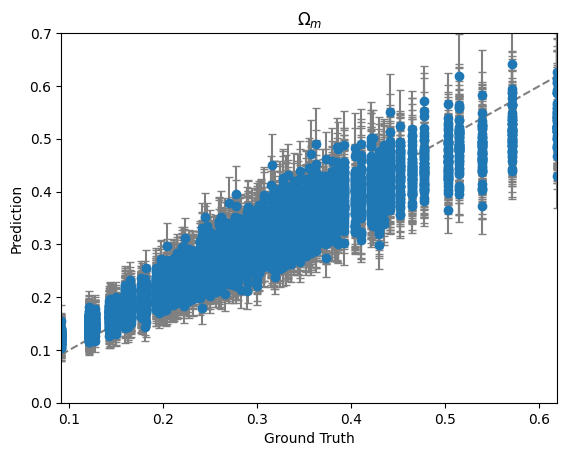

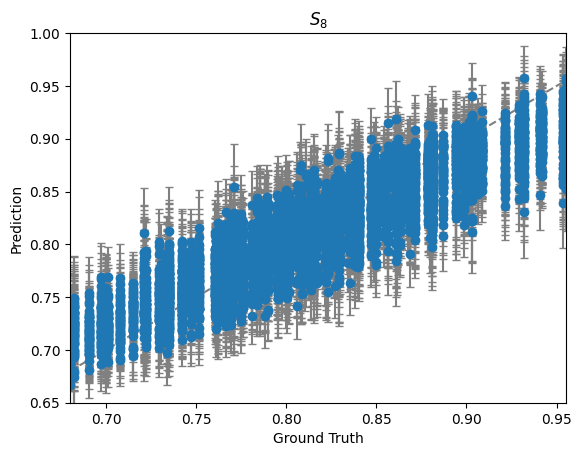

: 

In [ ]:
# Comparison of the means & standard deviations of the posterior distributions and the validation labels

plt.errorbar(y_val[:,0], mean_val[:,0], yerr=errorbar_val[:,0], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,0]), sorted(y_val[:,0]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,0]), np.max(y_val[:,0]))
plt.ylim(0, 0.7)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$\Omega_m$')
plt.show()

plt.errorbar(y_val[:,1], mean_val[:,1], yerr=errorbar_val[:,1], 
             fmt='o', capsize=3, capthick=1, ecolor='grey')
plt.plot(sorted(y_val[:,1]), sorted(y_val[:,1]),
         color = 'grey', linestyle='dashed')
plt.xlim(np.min(y_val[:,1]), np.max(y_val[:,1]))
plt.ylim(0.65, 1)
plt.xlabel('Ground Truth')
plt.ylabel('Prediction')
plt.title(r'$S_8$')
plt.show()

In [ ]:
validation_score = Score._score_phase1(
    true_cosmo=y_val,
    infer_cosmo=mean_val,
    errorbar=errorbar_val
)
print('averaged score:', np.mean(validation_score))
print('averaged error bar:', np.mean(errorbar_val, 0))

# Save the validation score as a JSON file
scoring_output = {"validation_score": float(validation_score),
                  "num_val": Nval,
                  "num_train": Ntrain}

with open(f"scoring_output/{MODEL_NAME}.json", "w") as f:
    json.dump(scoring_output, f, indent=2)

print(f"Validation score saved to scoring_output/{MODEL_NAME}.json: {validation_score}")

averaged score: 10.031935572072987
averaged error bar: [0.03980325 0.03160855]
Validation score saved to scoring_output/CNN_direct_clean_small_filter_robust_V15.json: 10.031935572072987


: 

In [ ]:
# Calculate percentage error while avoiding division by zero
# Method 1: Using boolean masking to exclude zeros
non_zero_mask = y_val != 0
percentage_error_masked = np.full_like(y_val, np.nan)  # Initialize with NaN
percentage_error_masked[non_zero_mask] = (y_val[non_zero_mask] - mean_val[non_zero_mask]) / y_val[non_zero_mask] * 100

# Calculate mean percentage error (NaN values are automatically ignored)
mean_percentage_error_masked = np.nanmean(percentage_error_masked, axis=0)

print(" Boolean masking to exclude zeros:")
print(f"  Ω_m: {mean_percentage_error_masked[0]:.2f}%")
print(f"  S_8: {mean_percentage_error_masked[1]:.2f}%")
print(f"  Overall: {np.nanmean(percentage_error_masked):.2f}%")



 Boolean masking to exclude zeros:
  Ω_m: -3.73%
  S_8: 0.05%
  Overall: -1.84%


: 

# 6 - Phase one Test inference

### Estimate the summary statistics $\boldsymbol{d}$ for all test data

In [ ]:
test_dataset = CosmologyDataset(
    data=data_obj.kappa_test, 
    transform=transform
)

test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

: 

In [ ]:
model.eval()
means_pred_list, sigmas_pred_list = [], []
pbar = tqdm(test_loader, total=len(test_loader), desc="Inference on the test set")
with torch.no_grad():
    for X in pbar:
        X = X.to(config.DEVICE)
        means_pred, sigmas_pred = model(X)         
        means_pred_list.append(means_pred.cpu().numpy()) 
        sigmas_pred_list.append(sigmas_pred.cpu().numpy())
        
mean = np.concatenate(means_pred_list, axis=0)
mean = label_scaler.inverse_transform(mean)          # inverse transform

errorbar = np.concatenate(sigmas_pred_list, axis=0)
errorbar = errorbar*label_scaler.var_**0.5           # rescale by the training label std

Inference on the test set: 100%|██████████| 63/63 [00:04<00:00, 13.99it/s]


: 

In [ ]:
## Include the prior that the cosmological parameters are not negative
negative_mask = mean - errorbar < 0
errorbar[negative_mask] = mean[negative_mask]

: 

#### ⚠️ NOTE:
- `mean`: a 2D array containing the point estimates of 2 cosmological parameters $\hat{\Omega}_m$ and $\hat{S}_8$.
- `errorbar`: a 2D array containing the one-standard deviation uncertainties of 2 cosmological parameters $\hat{\sigma}_{\Omega_m}$ and  $\hat{\sigma}_{S_8}$.
 
The shapes of `mean`, and `errorbar` must be $(N_{\rm test}, 2)$.

***

# 7 - (Optional) Prepare submission for Codabench

***

This section will save the model predictions `mean` and `errorbar` (both are 2D arrays with shape `(4000, 2)`, where `4000` is the number of test instances and `2` is the number of our parameters of interest) as a dictionary in a JSON file `result.json`. Then it will compress `result.json` into a zip file that can be directly submitted to Codabench.

***

In [ ]:
data = {"means": mean.tolist(), "errorbars": errorbar.tolist()}
the_date = datetime.datetime.now().strftime("%y-%m-%d-%H-%M")
zip_file_name = 'Submission_' + the_date + '.zip'
zip_file = Utility.save_json_zip(
    submission_dir="submissions",
    json_file_name="result.json",
    zip_file_name=zip_file_name,
    data=data
)
print(f"Submission ZIP saved at: {zip_file}")

Submission ZIP saved at: submissions/Submission_25-11-13-17-08.zip


: 

: 